<h1 style="text-align: center; font-family: 'Roboto', sans-serif; font-weight:bold; font-size:40px; margin: 40px 0">04 - EDA : Analyse</h1>

### Objectif
Dans ce document il est question de visualiser le dataframe pour identifier les caractéristiques qui distinguent les employés ayant quitté l'entreprise (`has_left = 1`) de ceux étant restés (`has_left = 0`). 

### Plan de ce notebook
- Importation des bibliothèques nécessaires
- Corrélation entre les variables
- Comparaison avec l'attrition
- Synthèse

### Prérequis

- Avoir exécuté les notebooks [EDA - Données Statiques](./01_eda_static_data.ipynb), [EDA - Feature Engineering Temporel](./02_eda_temporal_and_outliers.ipynb) et [EDA - Fusion des Données](./03_eda_merge_data.ipynb).

---
## **1. Importation des Bibliothèques Nécessaires**

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
from sklearn.preprocessing import MinMaxScaler

# On met en place les styles globaux
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor': '#FFFFFF',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# On met en place les palettes pour les départs vs restés
# En bleu = ceux qui sont restés
# En rouge = ceux qui sont partis
PALETTE = {0: '#4A90D9', 1: '#E05C5C'}
SNS_PALETTE = ['#4A90D9', '#E05C5C']
LABELS  = {0: 'Resté (0)', 1: 'Parti (1)'}

print('Les bibliothèques ont été importées correctement !')

Les bibliothèques ont été importées correctement !


In [32]:
# On récupère les données
df = pd.read_csv('../data/processed/merged_data.csv')
print(f"Dimensions : {df.shape}")
df.head()

Dimensions : (4410, 24)


,has_left,business_travel,department,education,education_field,job_level,job_role,monthly_income,percent_salary_hike,total_working_years,...,environment_satisfaction,job_satisfaction,work_life_balance,job_involvement,performance_rating,avg_hours_per_day,std_hours_daily,std_hours_monthly,total_days_worked,overtime_ratio
0,0,1,Sales,2,LifeSci,1,HealthRep,131160,11,1,...,3,4,2,3,3,7.373651,0.283224,0.051012,232,0.000000
1,1,2,R&D,1,LifeSci,1,Scientist,41890,23,6,...,3,2,4,2,4,7.718969,0.313351,0.080174,236,0.177966
2,0,2,R&D,4,Other,4,SalesExec,193280,15,5,...,2,2,1,3,3,7.013240,0.311551,0.069011,242,0.000000
3,0,0,R&D,5,LifeSci,3,HR,83210,11,13,...,4,4,3,2,3,7.193678,0.284133,0.069819,235,0.000000
4,0,1,R&D,1,Medical,1,SalesExec,23420,12,9,...,4,1,3,3,3,8.006175,0.300656,0.048139,245,0.469388


---
## **2. Corrélation entre les variables**

Dans cette section, il est question de déterminer la corrélation entre les variables. En effet, certaines peuvent être pertinentes à conserver pour de la visualisation de données, mais elles peuvent être liées l'une à l'autre ce qui risque d'influencer le modèle de prédiction et seront donc retirer lors de l'entraînement final.

Nous effectuerons ceci selon le plan suivant :
- Corrélation Globale.
- Corrélation Spécifique au taux d'attrition
- Taux d'attrition dans l'entreprise

### 2.1. Corrélation Globale

On remarque que certaines variables présentent une forte corrélation, comme par exemple entre le taux de jour avec heures supplémentaires et le nombre d'heures moyennes par jour (`0.91`), ce qui est logique. 

Chacune des variables dont la corrélation est assez prononcée par rapport à l'ensemble du dataframe fera l'objet d'une sélection.

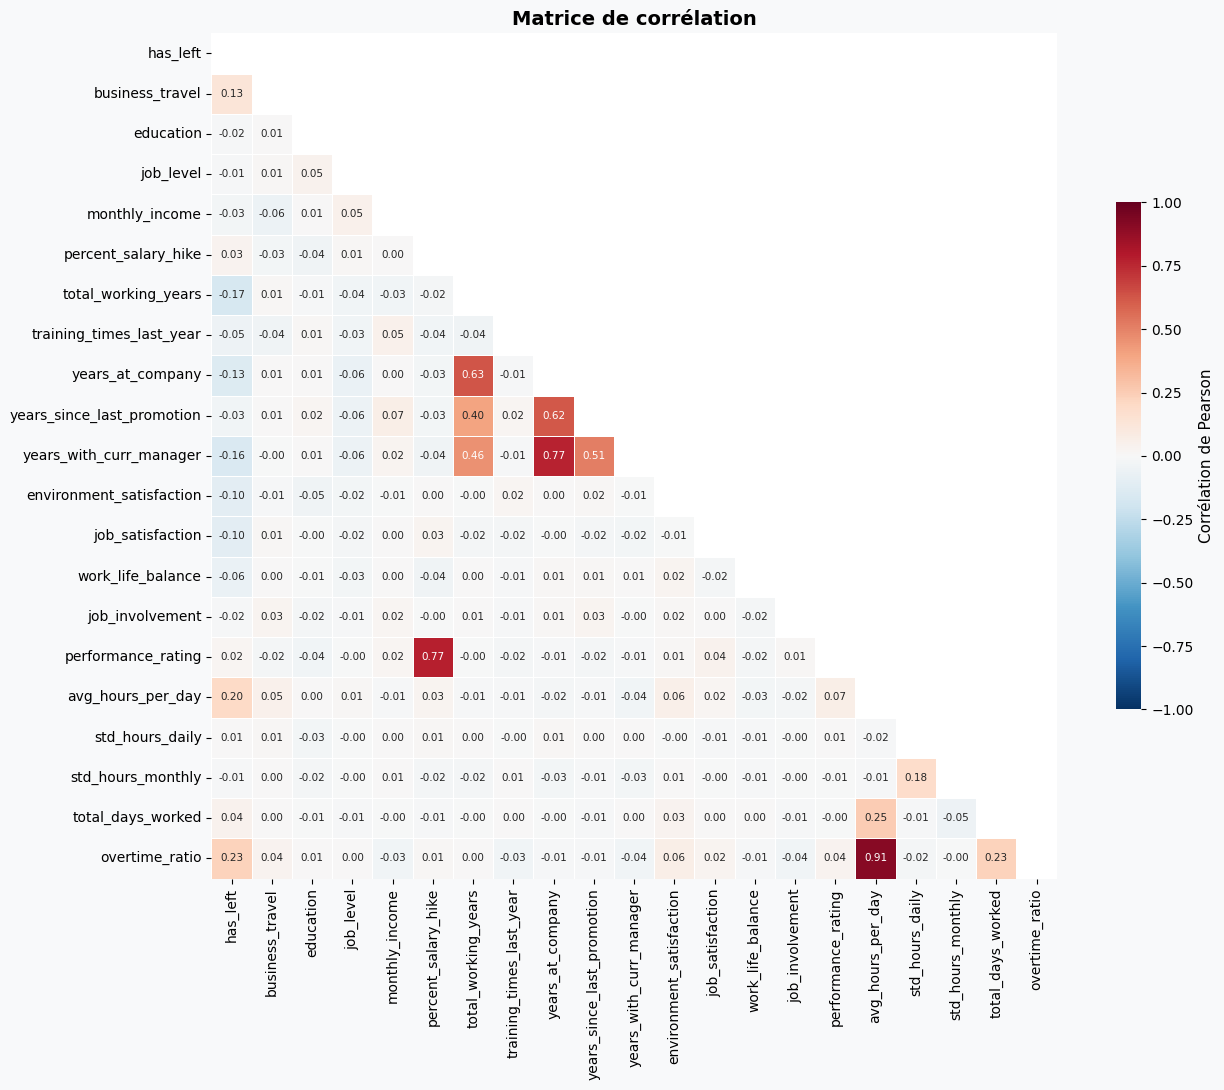

In [33]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    linewidths=0.4, square=True,
    cbar_kws={'shrink': 0.6, 'label': 'Corrélation de Pearson'}
)
ax.set_title('Matrice de corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2. Corrélation Spécifique

De la même manière, il est important de rappeler que notre sujet d'étude se situe autour de la variable `has_left`, il est donc intéressant de visualiser spécifiquement l'implication de chaque variable dans la détermination de celle-ci.

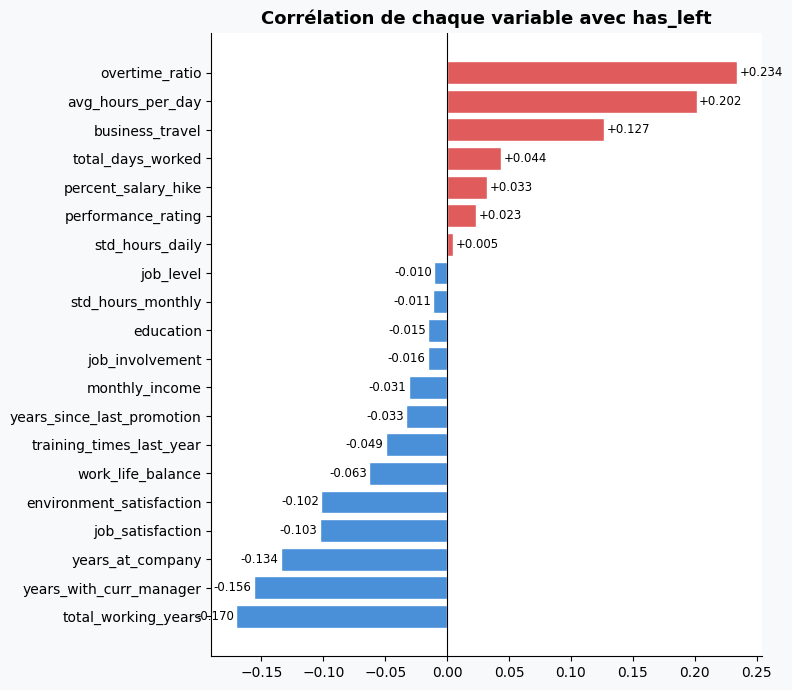

In [34]:
corr_target = corr['has_left'].drop('has_left').sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = [SNS_PALETTE[1] if v > 0 else SNS_PALETTE[0] for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélation de chaque variable avec has_left', fontsize=13, fontweight='bold')

for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8.5)
plt.tight_layout()
plt.show()

### 2.3. Taux d'attrition dans l'entreprise

Enfin, puisque nous nous intéressons spécifiquement à l'attrition, il peut être intéressant de visualiser celui-ci sous forme de Pi-Chart.

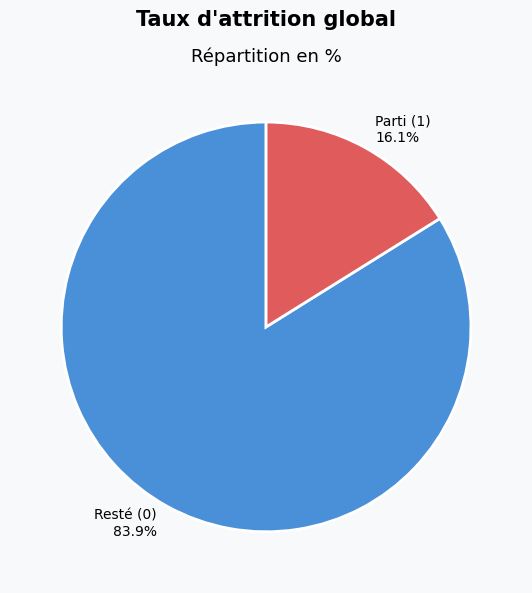

In [35]:
counts = df['has_left'].value_counts().sort_index()
pcts = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 6))
fig.suptitle("Taux d'attrition global", fontsize=15, fontweight='bold')

ax.pie(
    counts.values, labels=[f"{LABELS[k]}\n{pcts[k]:.1f}%" for k in counts.index],
    colors=[PALETTE[k] for k in counts.index],
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
ax.set_title('Répartition en %')

plt.tight_layout()
plt.show()

---
## **3. Comparaison avec l'attrition**

Dans cette section, nous allons étudier les différentes variables avec leur proportion respective d'attrition pour établir les profils types associés à ce taux. Nous allons le faire selon le plan suivant :
- Taux d'attrition par rôle
- Distributions en fonction des revenus
- Distribution par rapport à l'ancienneté
- Charge de travail

### 3.1. Taux d'attrition

#### 3.1.1. Par rôle

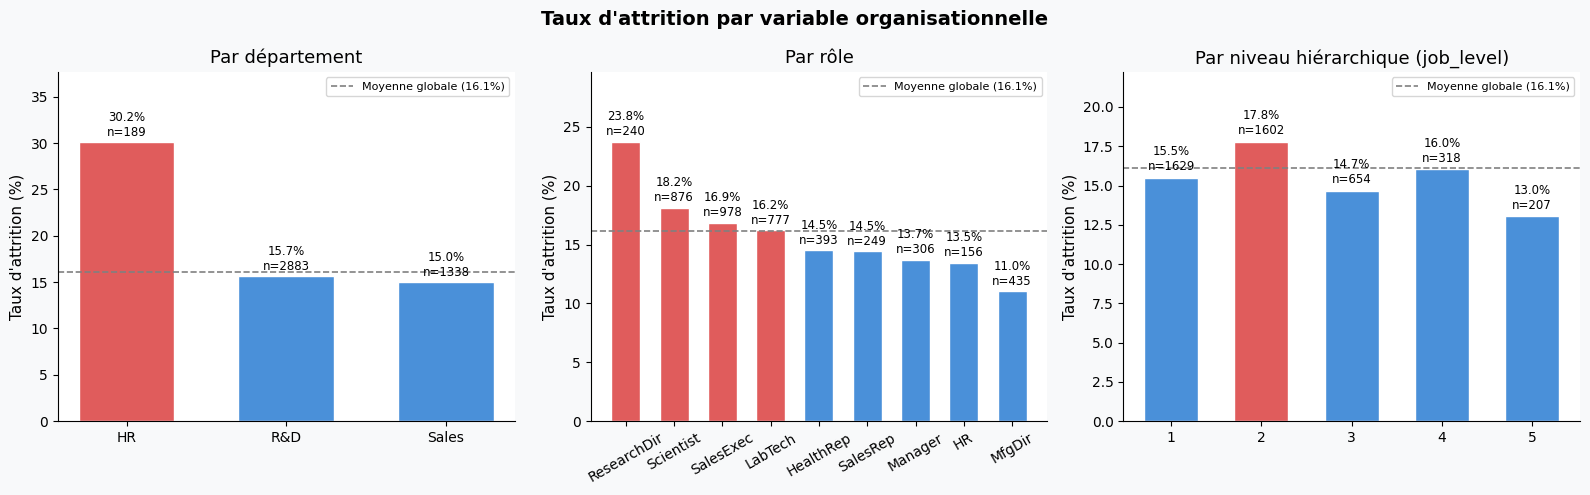

In [36]:
# Fonction permettant d'afficher le taux d'attrition par rapport à des variables catégorielles
def attrition_rate_bar(ax, col, title, rotation=0, figsize=None):
    """Barres du taux d'attrition par modalité d'une variable catégorielle."""
    rates = (df.groupby(col)['has_left']
               .agg(['sum', 'count'])
               .assign(rate=lambda x: x['sum'] / x['count'] * 100)
               .sort_values('rate', ascending=False))
    bars = ax.bar(rates.index, rates['rate'],
                  color=[SNS_PALETTE[1] if r > df['has_left'].mean()*100 else SNS_PALETTE[0]
                         for r in rates['rate']],
                  edgecolor='white', width=0.6)
    ax.axhline(df['has_left'].mean()*100, color='grey', linestyle='--',
               linewidth=1.2, label=f"Moyenne globale ({df['has_left'].mean()*100:.1f}%)")
    for bar, (idx, row) in zip(bars, rates.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{row['rate']:.1f}%\nn={int(row['count'])}",
                ha='center', va='bottom', fontsize=8.5)
    ax.set_title(title)
    ax.set_ylabel('Taux d\'attrition (%)')
    ax.set_ylim(0, rates['rate'].max() * 1.25)
    ax.tick_params(axis='x', rotation=rotation)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Taux d\'attrition par variable organisationnelle', fontsize=14, fontweight='bold')

attrition_rate_bar(axes[0], 'department', 'Par département')
attrition_rate_bar(axes[1], 'job_role', 'Par rôle', rotation=30)
attrition_rate_bar(axes[2], 'job_level', 'Par niveau hiérarchique (job_level)')

plt.tight_layout()
plt.show()

#### 3.1.2. Taux d'attrition par voyage & niveau d'études

De la même manière il est intéressant de visualiser le taux d'attrition en fonction du niveau d'étude et de la fréquence de voyage.

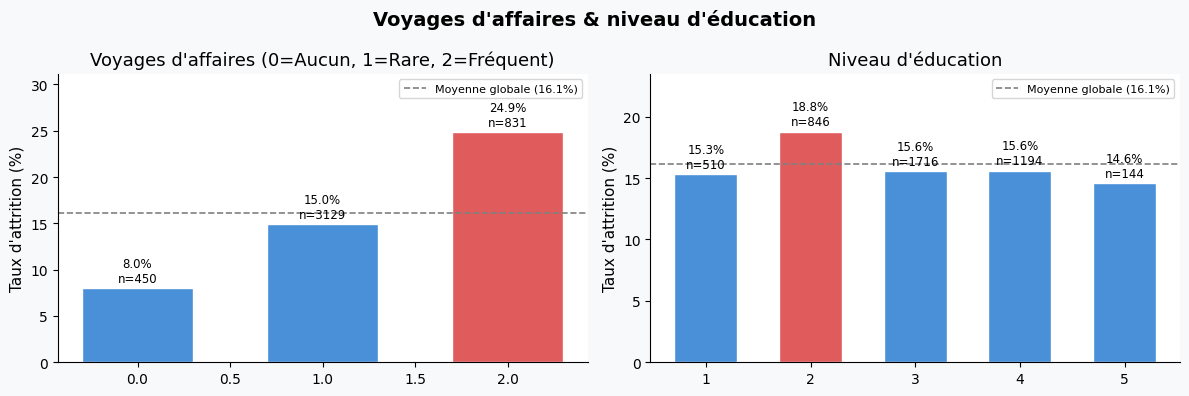

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Voyages d\'affaires & niveau d\'éducation', fontsize=14, fontweight='bold')

attrition_rate_bar(axes[0], 'business_travel', 'Voyages d\'affaires (0=Aucun, 1=Rare, 2=Fréquent)')
attrition_rate_bar(axes[1], 'education', 'Niveau d\'éducation')

plt.tight_layout()
plt.show()

#### 3.1.3. Taux d'attrition selon l'engagement

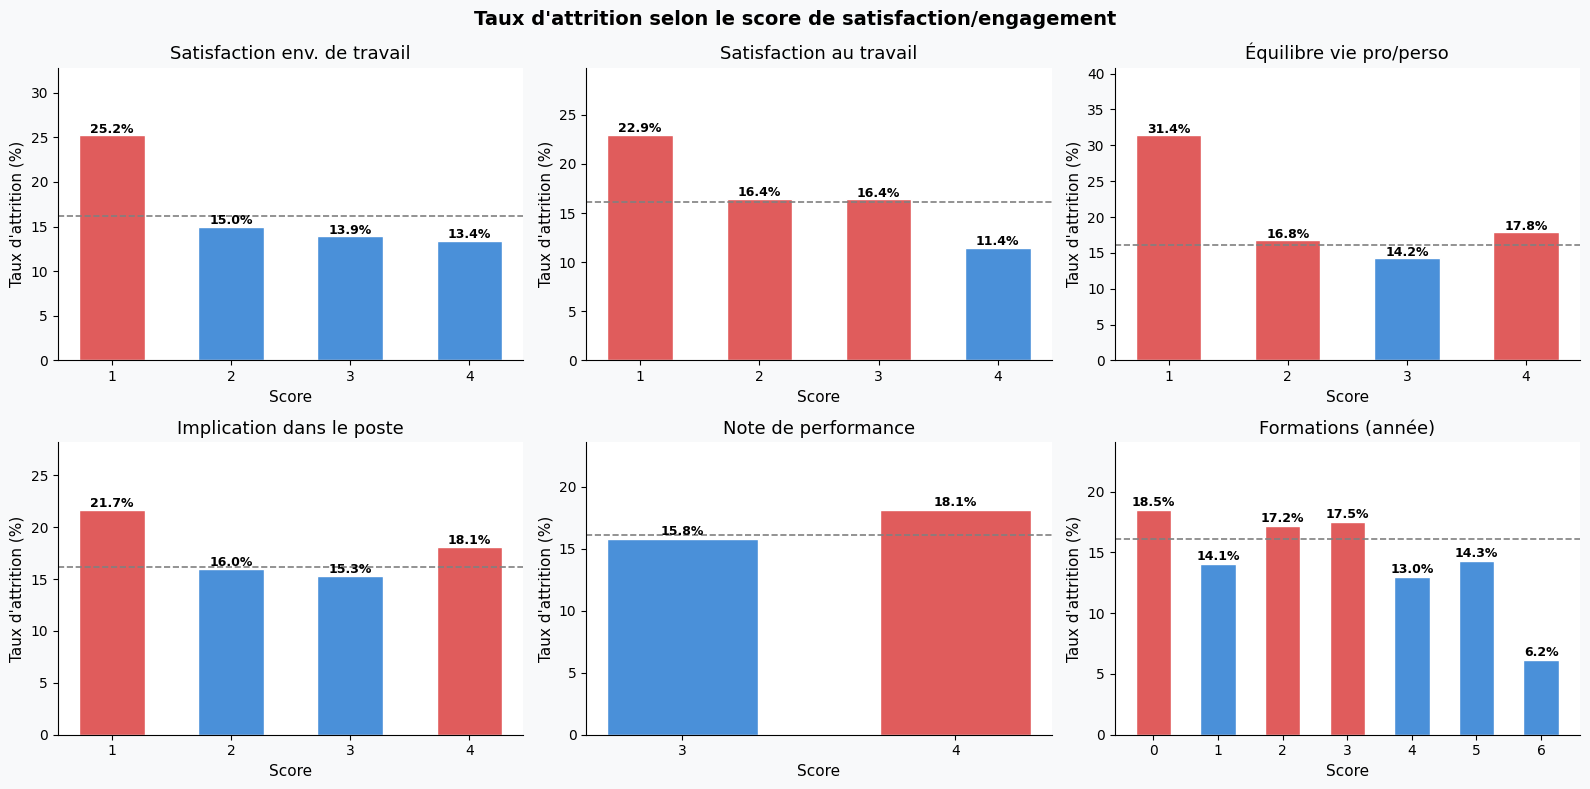

In [38]:
# On définit les colonnes sur lesquelles on va agir
satisfaction_cols = {
    'environment_satisfaction': 'Satisfaction env. de travail',
    'job_satisfaction':         'Satisfaction au travail',
    'work_life_balance':        'Équilibre vie pro/perso',
    'job_involvement':          'Implication dans le poste',
    'performance_rating':       'Note de performance',
    'training_times_last_year': 'Formations (année)',
}

# Taux d'attrition par score de satisfaction
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Taux d\'attrition selon le score de satisfaction/engagement', fontsize=14, fontweight='bold')

for ax, (col, label) in zip(axes.flatten(), satisfaction_cols.items()):
    rates = df.groupby(col)['has_left'].mean() * 100
    bars  = ax.bar(rates.index.astype(str), rates.values,
                   color=[SNS_PALETTE[1] if r > df['has_left'].mean()*100 else SNS_PALETTE[0]
                          for r in rates.values],
                   edgecolor='white', width=0.55)
    ax.axhline(df['has_left'].mean()*100, color='grey', linestyle='--', linewidth=1.2)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(label)
    ax.set_xlabel('Score')
    ax.set_ylabel('Taux d\'attrition (%)')
    ax.set_ylim(0, rates.max() * 1.3)

plt.tight_layout()
plt.show()

### 3.2. Distributions en fonction des revenus

Il peut être intéressant de se demander si l'aspect financier n'a pas un rôle important dans l'attrition.

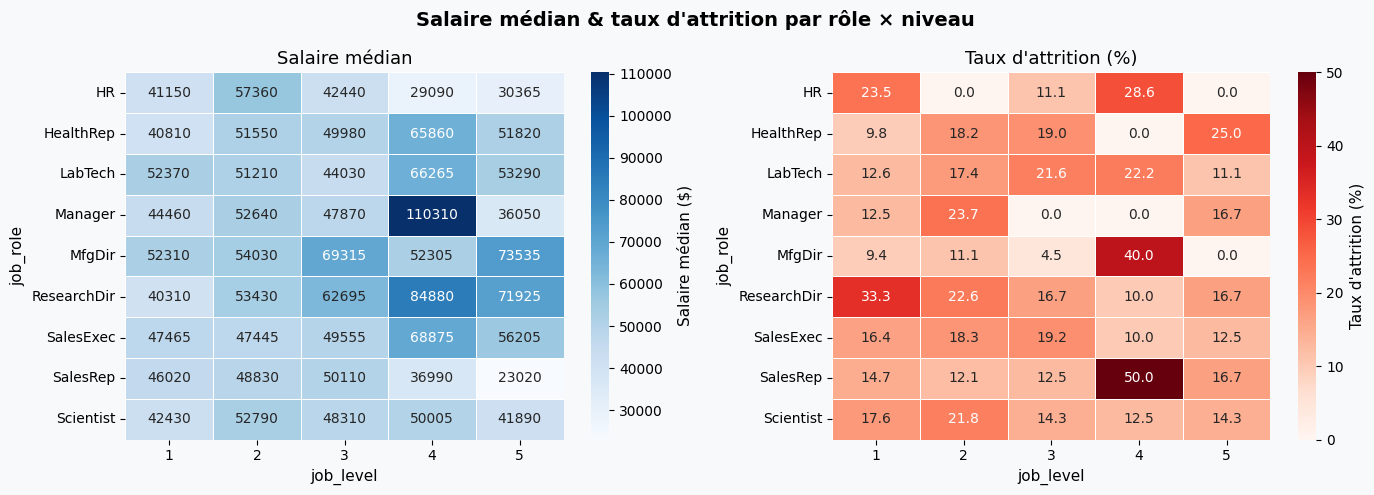

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Salaire médian & taux d\'attrition par rôle × niveau', fontsize=14, fontweight='bold')

pivot_income = df.pivot_table(values='monthly_income', index='job_role', columns='job_level', aggfunc='median')
pivot_attr   = df.pivot_table(values='has_left', index='job_role', columns='job_level', aggfunc='mean') * 100

sns.heatmap(pivot_income, ax=axes[0], cmap='Blues', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Salaire médian ($)'})
axes[0].set_title('Salaire médian')

sns.heatmap(pivot_attr, ax=axes[1], cmap='Reds', annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Taux d\'attrition (%)'})
axes[1].set_title('Taux d\'attrition (%)')

plt.tight_layout()
plt.show()

### 3.3. Distribution par rapport à l'ancienneté

C:\Users\Gamas\AppData\Local\Temp\ipykernel_29484\4262393945.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Gamas\AppData\Local\Temp\ipykernel_29484\4262393945.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Resté (0)', 'Parti (1)'])
C:\Users\Gamas\AppData\Local\Temp\ipykernel_29484\4262393945.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Gamas\AppData\Local\Temp\ipykernel_29484\4262393945.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(

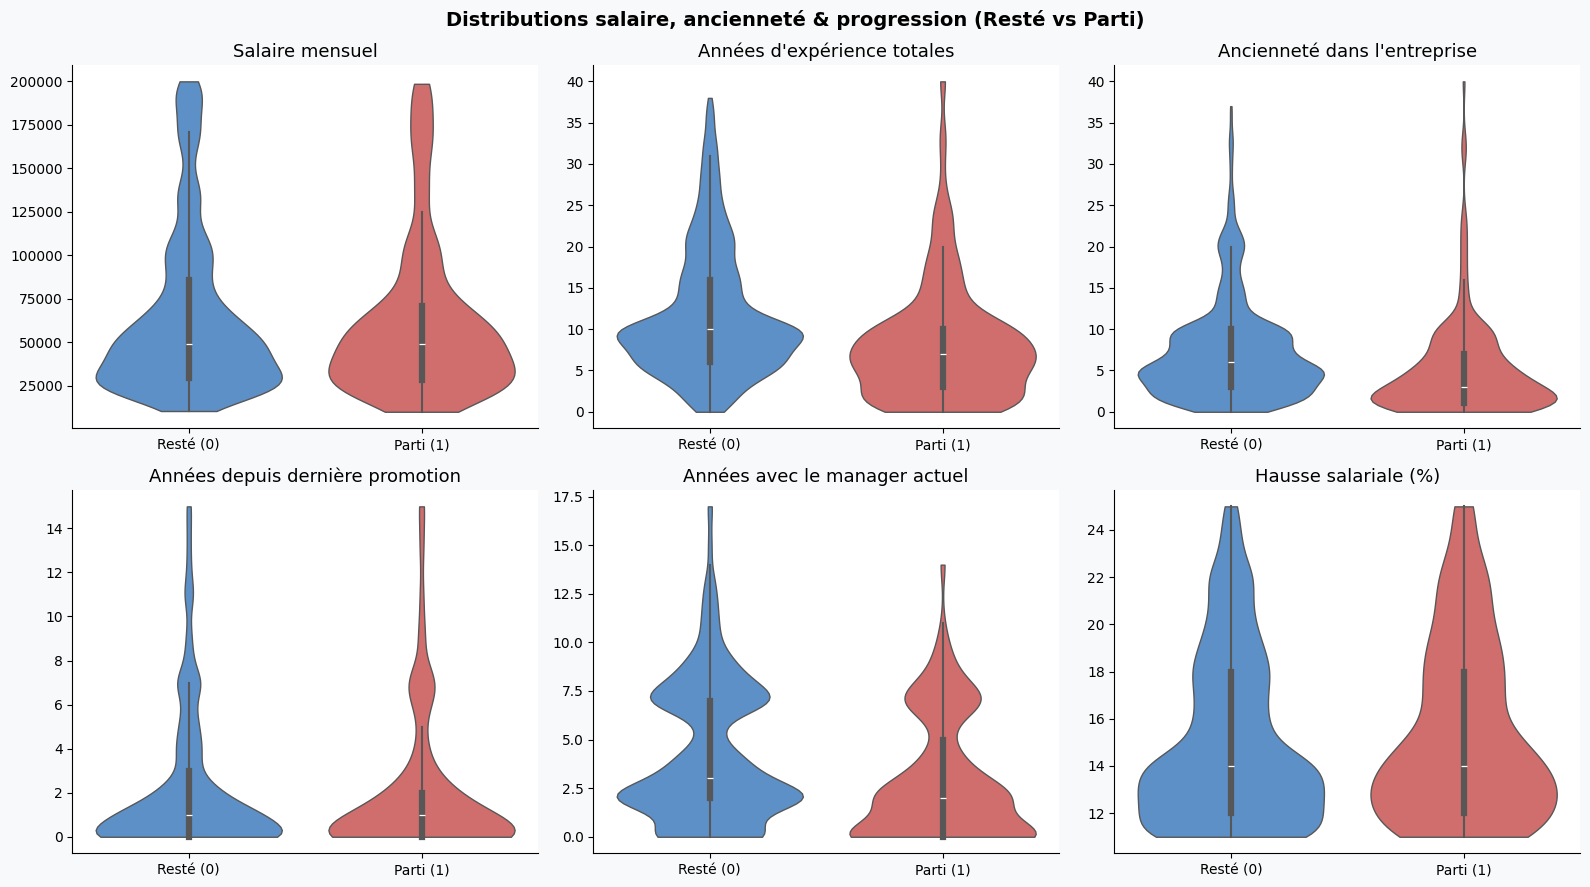

In [40]:
num_career = [
    ('monthly_income', 'Salaire mensuel'),
    ('total_working_years', 'Années d\'expérience totales'),
    ('years_at_company', 'Ancienneté dans l\'entreprise'),
    ('years_since_last_promotion', 'Années depuis dernière promotion'),
    ('years_with_curr_manager', 'Années avec le manager actuel'),
    ('percent_salary_hike', 'Hausse salariale (%)'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distributions salaire, ancienneté & progression (Resté vs Parti)', fontsize=14, fontweight='bold')

for ax, (col, label) in zip(axes.flatten(), num_career):
    sns.violinplot(
        data=df, x='has_left', y=col, ax=ax,
        palette=SNS_PALETTE, inner='box', cut=0, linewidth=1
    )
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_xticklabels(['Resté (0)', 'Parti (1)'])
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### 3.4. Charge de travail

Enfin, on peut également comparer par rapport à la charge de travail.

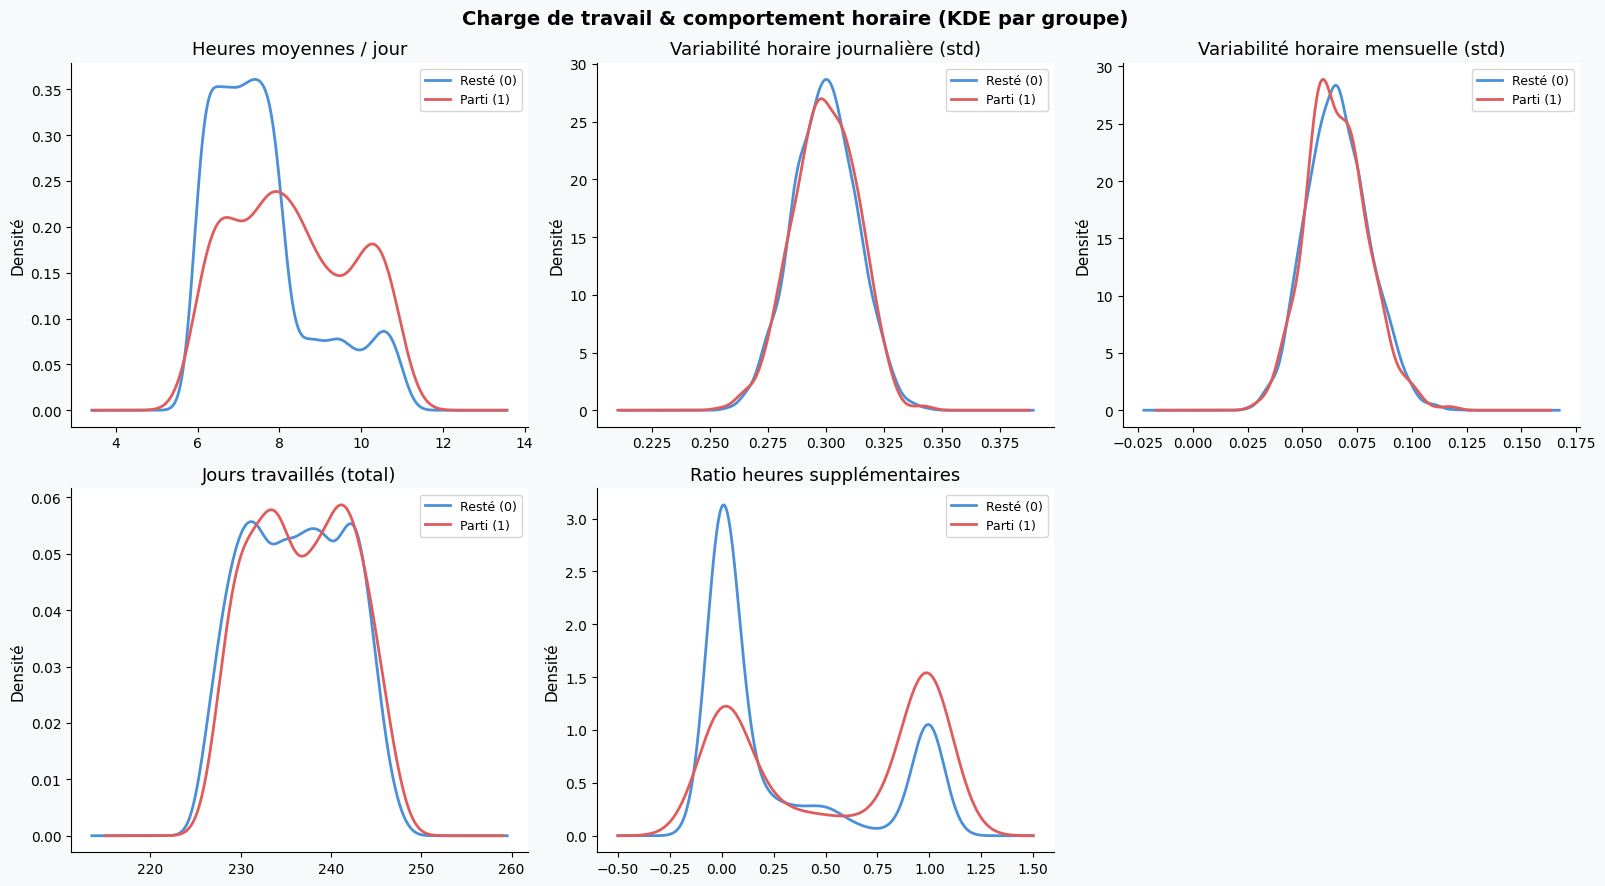

In [41]:
workload_cols = [
    ('avg_hours_per_day',  'Heures moyennes / jour'),
    ('std_hours_daily',    'Variabilité horaire journalière (std)'),
    ('std_hours_monthly',  'Variabilité horaire mensuelle (std)'),
    ('total_days_worked',  'Jours travaillés (total)'),
    ('overtime_ratio',     'Ratio heures supplémentaires'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Charge de travail & comportement horaire (KDE par groupe)', fontsize=14, fontweight='bold')

for ax, (col, label) in zip(axes.flatten(), workload_cols):
    for grp, color in PALETTE.items():
        subset = df[df['has_left'] == grp][col].dropna()
        subset.plot.kde(ax=ax, color=color, label=LABELS[grp], linewidth=2)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=9)

axes[1][2].set_visible(False)

plt.tight_layout()
plt.show()

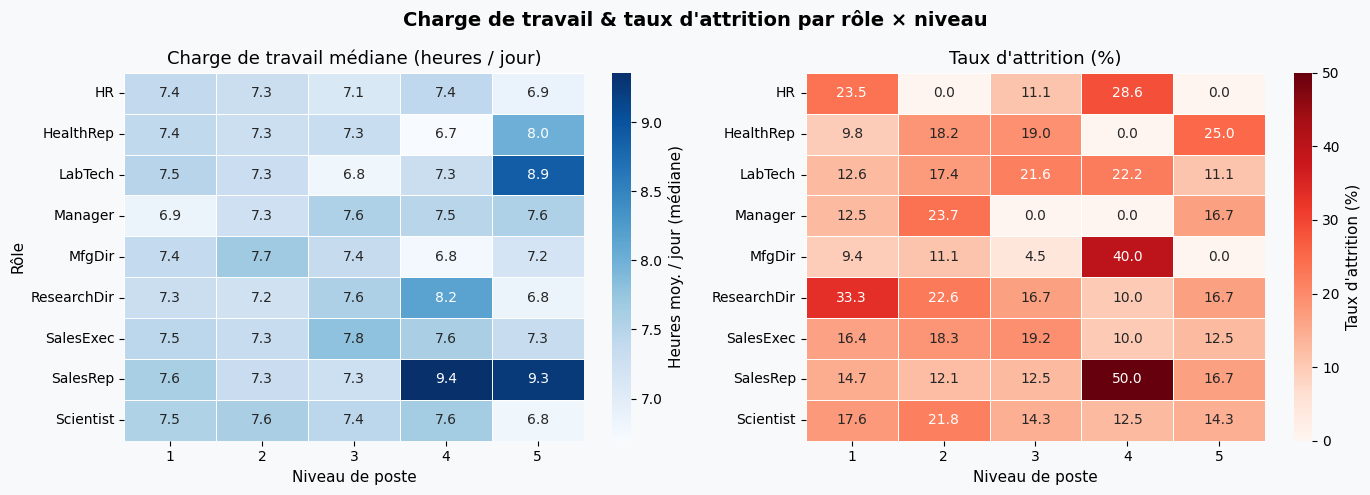

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Charge de travail & taux d\'attrition par rôle × niveau', fontsize=14, fontweight='bold')

pivot_workload = df.pivot_table(
    values='avg_hours_per_day',
    index='job_role',
    columns='job_level',
    aggfunc='median'
)
pivot_attr = df.pivot_table(
    values='has_left',
    index='job_role',
    columns='job_level',
    aggfunc='mean'
) * 100

sns.heatmap(pivot_workload, ax=axes[0], cmap='Blues', annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Heures moy. / jour (médiane)'})
axes[0].set_title('Charge de travail médiane (heures / jour)')
axes[0].set_xlabel('Niveau de poste')
axes[0].set_ylabel('Rôle')

sns.heatmap(pivot_attr, ax=axes[1], cmap='Reds', annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Taux d\'attrition (%)'})
axes[1].set_title('Taux d\'attrition (%)')
axes[1].set_xlabel('Niveau de poste')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

---
## **4. Synthèse**

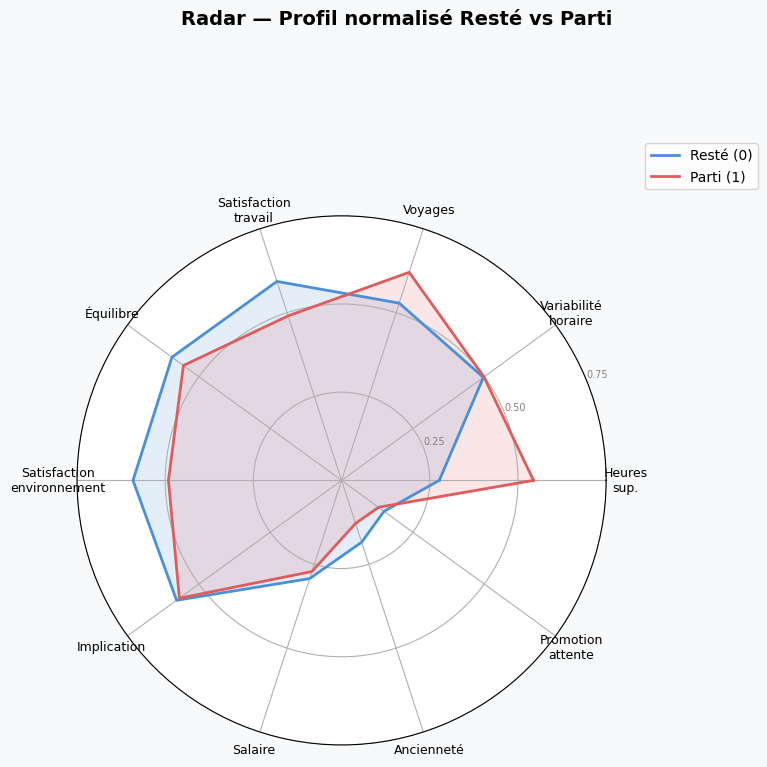

In [ ]:
radar_vars = [
    'overtime_ratio', 'std_hours_daily', 'business_travel',
    'job_satisfaction', 'work_life_balance', 'environment_satisfaction',
    'job_involvement', 'monthly_income', 'years_at_company',
    'years_since_last_promotion'
]
radar_labels = [
    'Heures\nsup.', 'Variabilité\nhoraire', 'Voyages', 'Satisfaction\ntravail',
    'Équilibre', 'Satisfaction\nenvironnement', 'Implication',
    'Salaire', 'Ancienneté', 'Promotion\nattente'
]

# On normalise les variables pour les mettre sur la même échelle [0,1]
scaler = MinMaxScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[radar_vars]), columns=radar_vars)
scaled['has_left'] = df['has_left'].values

means = scaled.groupby('has_left')[radar_vars].mean()

N = len(radar_vars)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Profil normalisé Resté vs Parti', fontsize=14, fontweight='bold', y=1.02)

for grp, color in PALETTE.items():
    vals = means.loc[grp].tolist() + [means.loc[grp].tolist()[0]]
    ax.plot(angles, vals, color=color, linewidth=2, label=LABELS[grp])
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['0.25', '0.50', '0.75'], fontsize=7, color='grey')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15))
plt.tight_layout()
plt.show()

| Dimension | Signal détecté |
|---|---|
| **Rôle & département** | Sales Exec & Lab Tech dans Sales / HR sur-représentés |
| **Niveau hiérarchique** | Niveaux bas (1–2) partent davantage |
| **Salaire** | Salaire médian plus faible pour les partants |
| **Ancienneté** | Moins d'années dans l'entreprise et d'expérience totale |
| **Promotion** | Stagnation plus marquée (plus d'années sans promotion) |
| **Voyages** | Déplacements fréquents = taux d'attrition plus élevé |
| **Heures sup.** | `overtime_ratio` nettement plus élevé chez les partants |
| **Satisfaction** | Scores plus faibles sur job, environnement, équilibre |
| **Implication** | Job involvement et work-life balance dégradés |

**Profil synthétique :** employé junior, faiblement rémunéré, avec peu de perspectives de promotion, voyageant fréquemment, faisant beaucoup d'heures supplémentaires, et présentant de faibles scores de satisfaction.

---
<div style="display: flex; justify-content: space-between;">
  <a href="./03_eda_merge_data.ipynb">Précédent</a>
  <a href=""></a>
</div>